## Text Summarization
Take input corpus like brown or gutenberg and summarize using pretrained model
<br>
2 types of summaries - DESCRIPTIVE AND INFORMATIVE
<br>
Run the same flow 3 times (1 model + 1 corpus each), then compare metrics using a bar graph.

In [29]:
# !pip install -q nltk transformers torch evaluate rouge_score pandas

import nltk
from nltk.corpus import gutenberg, brown, inaugural
from transformers import pipeline
import evaluate
import pandas as pd

In [30]:
# -----------------------------
# RUN 1: Model 1 + Corpus 1
# -----------------------------
file_id_1 = 'melville-moby_dick.txt'
raw_text_1 = gutenberg.raw(file_id_1)
corpus_label_1 = f'Gutenberg: {file_id_1}'

input_text_1 = raw_text_1
print('Selected corpus:', corpus_label_1)
print('Input length:', len(input_text_1))

summarizer_1 = pipeline('summarization', model='sshleifer/distilbart-cnn-12-6')

safe_input_text_1 = summarizer_1.tokenizer.decode(
    summarizer_1.tokenizer.encode(input_text_1, truncation=True, max_length=1000),
    skip_special_tokens=True
)

descriptive_summary_raw_1 = summarizer_1(
    f"This text is about: {safe_input_text_1}",
    max_length=30,
    min_length=10,
    do_sample=False
)[0]['summary_text']
descriptive_summary_1 = f"This document provides an overview of {descriptive_summary_raw_1.strip()}."

informative_summary_1 = summarizer_1(
    safe_input_text_1,
    max_length=250,
    min_length=50,
    do_sample=False
)[0]['summary_text']

print('DESCRIPTIVE SUMMARY (Topic-focused):\n', descriptive_summary_1)
print('\nINFORMATIVE SUMMARY (Content-focused):\n', informative_summary_1)

reference_summary_1 = ' '.join(nltk.sent_tokenize(safe_input_text_1)[::2])

rouge_1 = evaluate.load('rouge')
rouge_scores_1 = rouge_1.compute(
    predictions=[informative_summary_1],
    references=[reference_summary_1]
)

bleu_1 = evaluate.load('bleu')
bleu_scores_1 = bleu_1.compute(
    predictions=[informative_summary_1],
    references=[[reference_summary_1]]
)

rouge1_1 = round(rouge_scores_1['rouge1'], 4)
rougeL_1 = round(rouge_scores_1['rougeL'], 4)
bleu_score_1 = round(bleu_scores_1['bleu'], 4)

print('ROUGE-1:', rouge1_1)
print('ROUGE-L:', rougeL_1)
print('BLEU   :', bleu_score_1)

result_1 = {
    'model': 'sshleifer/distilbart-cnn-12-6',
    'corpus': corpus_label_1,
    'ROUGE-1': rouge1_1,
    'ROUGE-L': rougeL_1,
    'BLEU': bleu_score_1
}

Selected corpus: Gutenberg: melville-moby_dick.txt
Input length: 1242990


Device set to use cpu


DESCRIPTIVE SUMMARY (Topic-focused):
 This document provides an overview of This text is about: [Moby Dick by Herman Melville 1851] The text was supplied by a Late Consumptive Us.

INFORMATIVE SUMMARY (Content-focused):
  The whale statements are not for veritable gospel cetology, but for entertaining . As a mere painstaking burrower and grub-worm of a Sub-Sub-Sub appears to have gone through the long .Vaticans and street-stalls of the earth, picking up whatever random references to whales he could find in any book whatsoever . Therefore you must not, in every case at least,take the . higgledy-piggledy whale statements, however authentic, in . However, these extracts are solely valuable or entertaining .
ROUGE-1: 0.34
ROUGE-L: 0.2933
BLEU   : 0.0454


In [31]:
# -----------------------------
# RUN 2: Model 2 + Corpus 2
# -----------------------------
raw_text_2 = ' '.join(brown.words(categories='news')[:10000])
corpus_label_2 = 'Brown: news'

input_text_2 = raw_text_2
print('Selected corpus:', corpus_label_2)
print('Input length:', len(input_text_2))

summarizer_2 = pipeline('summarization', model='facebook/bart-large-cnn')

safe_input_text_2 = summarizer_2.tokenizer.decode(
    summarizer_2.tokenizer.encode(input_text_2, truncation=True, max_length=1000),
    skip_special_tokens=True
)

descriptive_summary_raw_2 = summarizer_2(
    f"This text is about: {safe_input_text_2}",
    max_length=30,
    min_length=10,
    do_sample=False
)[0]['summary_text']
descriptive_summary_2 = f"This document provides an overview of {descriptive_summary_raw_2.strip()}."

informative_summary_2 = summarizer_2(
    safe_input_text_2,
    max_length=250,
    min_length=50,
    do_sample=False
)[0]['summary_text']

print('DESCRIPTIVE SUMMARY (Topic-focused):\n', descriptive_summary_2)
print('\nINFORMATIVE SUMMARY (Content-focused):\n', informative_summary_2)

reference_summary_2 = ' '.join(nltk.sent_tokenize(safe_input_text_2)[::2])

rouge_2 = evaluate.load('rouge')
rouge_scores_2 = rouge_2.compute(
    predictions=[informative_summary_2],
    references=[reference_summary_2]
)

bleu_2 = evaluate.load('bleu')
bleu_scores_2 = bleu_2.compute(
    predictions=[informative_summary_2],
    references=[[reference_summary_2]]
)

rouge1_2 = round(rouge_scores_2['rouge1'], 4)
rougeL_2 = round(rouge_scores_2['rougeL'], 4)
bleu_score_2 = round(bleu_scores_2['bleu'], 4)

print('ROUGE-1:', rouge1_2)
print('ROUGE-L:', rougeL_2)
print('BLEU   :', bleu_score_2)

result_2 = {
    'model': 'facebook/bart-large-cnn',
    'corpus': corpus_label_2,
    'ROUGE-1': rouge1_2,
    'ROUGE-L': rougeL_2,
    'BLEU': bleu_score_2
}

Selected corpus: Brown: news
Input length: 55764


Device set to use cpu


DESCRIPTIVE SUMMARY (Topic-focused):
 This document provides an overview of Fulton County Grand Jury says it found no evidence of irregularities in primary election. Jury says many of Georgia's registration and election laws are.

INFORMATIVE SUMMARY (Content-focused):
 Fulton County Grand Jury says it found no evidence of irregularities in primary election. Jury said it did find that many of Georgia's registration and election laws are outmoded or inadequate. Jury took a swipe at State Welfare Department's handling of federal funds granted for child welfare services in foster homes. Jury recommended four additional deputies be employed at Fulton County Jail.
ROUGE-1: 0.2716
ROUGE-L: 0.2586
BLEU   : 0.0016


In [32]:
# -----------------------------
# RUN 3: Model 3 + Corpus 3
# -----------------------------
file_id_3 = '2021-Biden.txt'
raw_text_3 = inaugural.raw(file_id_3)
corpus_label_3 = f'Inaugural: {file_id_3}'

input_text_3 = raw_text_3
print('Selected corpus:', corpus_label_3)
print('Input length:', len(input_text_3))

summarizer_3 = pipeline('summarization', model='sshleifer/distilbart-xsum-12-6')

safe_input_text_3 = summarizer_3.tokenizer.decode(
    summarizer_3.tokenizer.encode(input_text_3, truncation=True, max_length=1000),
    skip_special_tokens=True
)

descriptive_summary_raw_3 = summarizer_3(
    f"This text is about: {safe_input_text_3}",
    max_length=30,
    min_length=10,
    do_sample=False
)[0]['summary_text']
descriptive_summary_3 = f"This document provides an overview of {descriptive_summary_raw_3.strip()}."

informative_summary_3 = summarizer_3(
    safe_input_text_3,
    max_length=250,
    min_length=50,
    do_sample=False
)[0]['summary_text']

print('DESCRIPTIVE SUMMARY (Topic-focused):\n', descriptive_summary_3)
print('\nINFORMATIVE SUMMARY (Content-focused):\n', informative_summary_3)

reference_summary_3 = ' '.join(nltk.sent_tokenize(safe_input_text_3)[::2])

rouge_3 = evaluate.load('rouge')
rouge_scores_3 = rouge_3.compute(
    predictions=[informative_summary_3],
    references=[reference_summary_3]
)

bleu_3 = evaluate.load('bleu')
bleu_scores_3 = bleu_3.compute(
    predictions=[informative_summary_3],
    references=[[reference_summary_3]]
)

rouge1_3 = round(rouge_scores_3['rouge1'], 4)
rougeL_3 = round(rouge_scores_3['rougeL'], 4)
bleu_score_3 = round(bleu_scores_3['bleu'], 4)

print('ROUGE-1:', rouge1_3)
print('ROUGE-L:', rougeL_3)
print('BLEU   :', bleu_score_3)

result_3 = {
    'model': 'sshleifer/distilbart-xsum-12-6',
    'corpus': corpus_label_3,
    'ROUGE-1': rouge1_3,
    'ROUGE-L': rougeL_3,
    'BLEU': bleu_score_3
}


Selected corpus: Inaugural: 2021-Biden.txt
Input length: 13963


Device set to use cpu


DESCRIPTIVE SUMMARY (Topic-focused):
 This document provides an overview of Here is the full text of President Donald Trump's first speech as president..

INFORMATIVE SUMMARY (Content-focused):
 Here is the full text of President Donald Trump's speech, delivered on New Year's Day, at the US Capitol in Washington, DC, as he takes the oath to be the 45th president of the United States of America and the Republic of America.
ROUGE-1: 0.1083
ROUGE-L: 0.0658
BLEU   : 0.0


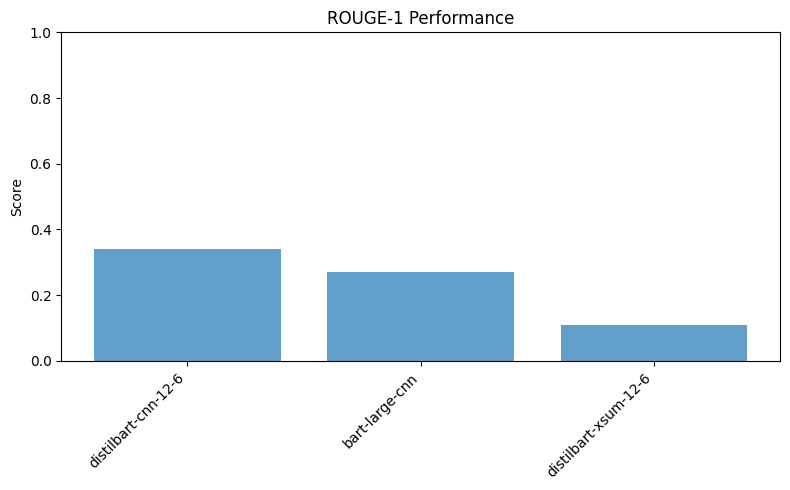

In [33]:

import matplotlib.pyplot as plt

comparison_df = pd.DataFrame([result_1, result_2, result_3])

# ROUGE-1 Graph
fig, ax = plt.subplots(figsize=(8, 5))
models = comparison_df['model'].str.split('/').str[-1]
values = comparison_df['ROUGE-1']
ax.bar(range(len(models)), values, color='#1f77b4', alpha=0.7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('ROUGE-1 Performance')
plt.tight_layout()
plt.show()

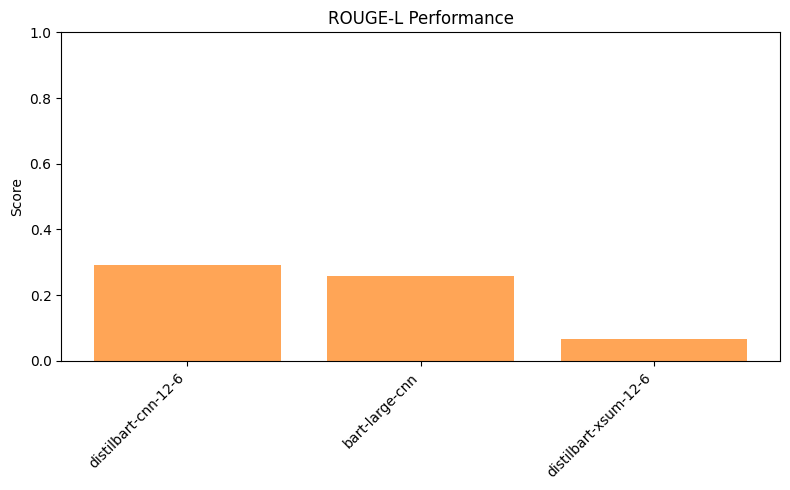

In [34]:
# ROUGE-L Graph
fig, ax = plt.subplots(figsize=(8, 5))
models = comparison_df['model'].str.split('/').str[-1]
values = comparison_df['ROUGE-L']
ax.bar(range(len(models)), values, color='#ff7f0e', alpha=0.7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('ROUGE-L Performance')
plt.tight_layout()
plt.show()

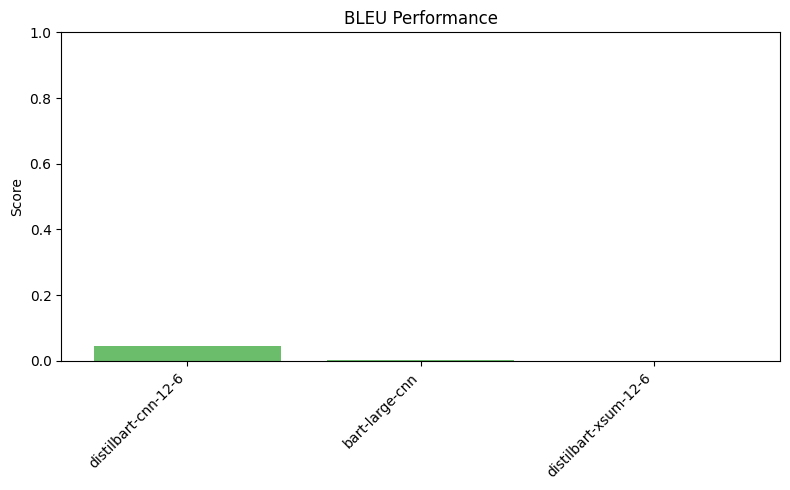

In [35]:
# BLEU Graph
fig, ax = plt.subplots(figsize=(8, 5))
models = comparison_df['model'].str.split('/').str[-1]
values = comparison_df['BLEU']
ax.bar(range(len(models)), values, color='#2ca02c', alpha=0.7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('BLEU Performance')
plt.tight_layout()
plt.show()